# Approaches to find candidate genes (genomic approach)

In [1]:
# open vcf file
import numpy as np
import cyvcf2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

SAMPLE   = "SBC10"
VCF_PATH = "../results/sift4g/SBC10.private.sift4g.vcf.gz"

## prepare dataframe

> **Alternative: one ANN per gene.** Unlike the baseline notebook (one row per SnpEff ANN *transcript* entry), `parse_vcf` here reduces each variant's many ANN entries to a single representative transcript **per gene**, following [`MULT_ANN_TO_ONE_ANN.md`](./MULT_ANN_TO_ONE_ANN.md):
> - **Case 1 — SIFT exists (apple-to-apple):** keep the ANN entry whose `(allele, transcript)` matches a `SIFTINFO` key, so the SnpEff effect and SIFT score sit on the same transcript.
> - **Case 2 — SIFT absent:** pick by a deterministic sort — impact severity → SnpEff ANN order → biotype.
>
> This removes the transcript-multiplicity inflation that previously affected the SUM gene-level approach.

In [2]:
ANN_FIELDS = [
    "ann_allele", "ann_effect", "ann_impact", "ann_gene_name", "ann_gene_id",
    "ann_feature_type", "ann_feature_id", "ann_biotype", "ann_rank",
    "ann_hgvs_c", "ann_hgvs_p", "ann_cdna_pos", "ann_cds_pos", "ann_aa_pos",
    "ann_distance", "ann_extra",
]

SIFT_FIELDS = [
    "sift_allele", "sift_transcript", "sift_gene_id", "sift_gene_name",
    "sift_region", "sift_variant_type", "sift_aa_change", "sift_aa_pos",
    "sift_score", "sift_median", "sift_num_seqs", "sift_allele_type",
    "sift_prediction",
]

# SIFT4G writes DELETERIOUS (score < 0.05) or TOLERATED; NA means non-coding
_SIFT_PRIORITY = {"DELETERIOUS": 0, "TOLERATED": 1}

# impact severity for tiebreaking (HIGH most severe -> lowest rank)
_IMPACT_RANK = {"HIGH": 0, "MODERATE": 1, "LOW": 2, "MODIFIER": 3}


def _parse_ann(raw: str) -> list[dict]:
    records = []
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(ANN_FIELDS) - len(parts))
        records.append(dict(zip(ANN_FIELDS, parts[:len(ANN_FIELDS)])))
    return records


def _parse_siftinfo(raw: str) -> dict:
    """Returns (allele, transcript) -> best SIFT record.

    Both SnpEff and SIFT4G are built from NCBIv3 GFF, so ann_feature_id and
    sift_transcript share the same XM_* namespace and can be joined directly.
    SIFT4G annotates one representative transcript per gene; unmatched ANN
    transcript rows receive no SIFT columns.
    """
    by_key: dict[tuple, dict] = {}
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(SIFT_FIELDS) - len(parts))
        d = dict(zip(SIFT_FIELDS, parts[:len(SIFT_FIELDS)]))
        key = (d["sift_allele"], d["sift_transcript"])
        pred = d.get("sift_prediction", "")
        current = by_key.get(key)
        if current is None or _SIFT_PRIORITY.get(pred, 99) < _SIFT_PRIORITY.get(current.get("sift_prediction", ""), 99):
            by_key[key] = d
    return by_key


def _reduce_annotations(annotations: list[dict], sift_by_key: dict) -> list[tuple]:
    """Reduce a variant's many ANN entries to ONE per gene (see MULT_ANN_TO_ONE_ANN.md).

    SnpEff emits one ANN per affected transcript, but SIFT4G anchors to a single
    representative transcript per gene. To make the two comparable we keep one
    ANN per gene, chosen by a single deterministic sort (lowest key wins):

      1. SIFT match  -- (allele, transcript) is a SIFTINFO key. This is Case 1
         (apple-to-apple): it pairs the SnpEff effect and the SIFT score on the
         SAME transcript. Top key, so a SIFT-anchored row always wins when present.

    When no entry matches SIFT (Case 2, gene-level umbrella), keys 2-4 decide:
      2. impact severity  -- HIGH > MODERATE > LOW > MODIFIER
      3. SnpEff ANN order -- severity proxy within an impact tier, captured here
         while the original ANN order is still intact
      4. biotype          -- prefer protein_coding over pseudogene / nc

    Returns a list of (ann, sift) pairs, one per gene.
    """
    by_gene: dict[str, list[tuple]] = {}
    for order, ann in enumerate(annotations):
        key = (ann.get("ann_allele", ""), ann.get("ann_feature_id", ""))
        sort_key = (
            0 if key in sift_by_key else 1,                          # 1. SIFT match (Case 1)
            _IMPACT_RANK.get(ann.get("ann_impact", ""), 99),         # 2. impact severity
            order,                                                   # 3. SnpEff ANN order
            0 if ann.get("ann_biotype") == "protein_coding" else 1,  # 4. biotype
        )
        by_gene.setdefault(ann.get("ann_gene_id", ""), []).append((sort_key, key, ann))

    reduced = []
    for entries in by_gene.values():
        _, key, ann = min(entries, key=lambda t: t[0])              # winner of the sort
        reduced.append((ann, sift_by_key.get(key, {})))
    return reduced


def parse_vcf(vcf_path: str) -> pd.DataFrame:
    """
    Parse a SIFT4G+SnpEff annotated VCF into a DataFrame.

    One row per (variant, gene): the many SnpEff ANN transcript entries are
    reduced to a single representative transcript per gene via
    _reduce_annotations (see MULT_ANN_TO_ONE_ANN.md), and the SIFT columns of
    that transcript are joined on. This is the key difference from the baseline
    notebook, which keeps one row per ANN transcript entry.
    """
    vcf = cyvcf2.VCF(vcf_path)
    rows = []
    for variant in vcf:
        gt_arr = variant.genotypes[0]
        sep = "|" if gt_arr[2] else "/"
        base = {
            "chrom":  variant.CHROM,
            "pos":    variant.POS,
            "ref":    variant.REF,
            "alt":    ",".join(variant.ALT),
            "qual":   variant.QUAL,
            "filter": variant.FILTER,
            "gt":     f"{gt_arr[0]}{sep}{gt_arr[1]}",
        }

        ann_raw  = variant.INFO.get("ANN")
        sift_raw = variant.INFO.get("SIFTINFO")
        if not ann_raw:
            rows.append(base)
            continue

        annotations = _parse_ann(ann_raw)
        sift_by_key = _parse_siftinfo(sift_raw) if sift_raw else {}
        for ann, sift in _reduce_annotations(annotations, sift_by_key):
            rows.append({**base, **ann, **sift})

    df = pd.DataFrame(rows)
    df["sift_score"] = pd.to_numeric(df.get("sift_score"), errors="coerce")
    df["sift_score_c"] = 1 - df["sift_score"]
    return df


In [3]:
df = parse_vcf(VCF_PATH)
df

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_region,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c
0,NC_012870.2,1619,G,A,54.540001,None,1|0,A,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NC_012870.2,1619,G,A,54.540001,None,1|0,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NC_012870.2,6934,A,G,31.510000,None,1|0,G,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727983,NC_012879.2,61233619,T,G,27.490000,None,1/1,G,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
727984,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
727985,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
727986,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Sanity check
- ANN field reduction check
- Confusion matrix of the no. of variants that have both/either SnpEff and/or SIFT

In [4]:
# sanity check: the reduction should leave exactly one row per (variant, gene)
key_cols = ["chrom", "pos", "ref", "alt", "ann_gene_id"]
dups = int(df.duplicated(subset=key_cols).sum())
print(f"total rows after reduction        : {len(df):,}")
print(f"distinct (variant, gene) groups   : {df.drop_duplicates(subset=key_cols).shape[0]:,}")
print(f"duplicate (variant, gene) rows     : {dups:,}  (expect 0)")

total rows after reduction        : 727,988
distinct (variant, gene) groups   : 727,988
duplicate (variant, gene) rows     : 0  (expect 0)


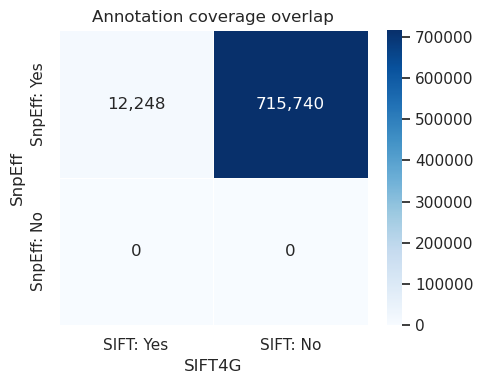

             SIFT: Yes  SIFT: No
SnpEff: Yes      12248    715740
SnpEff: No           0         0


In [5]:
has_snpeff = df['ann_impact'].notna()
has_sift   = df['sift_score_c'].notna()

cm = pd.DataFrame(
    {
        "SIFT: Yes": [(has_snpeff &  has_sift).sum(), (~has_snpeff &  has_sift).sum()],
        "SIFT: No":  [(has_snpeff & ~has_sift).sum(), (~has_snpeff & ~has_sift).sum()],
    },
    index=["SnpEff: Yes", "SnpEff: No"],
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title("Annotation coverage overlap")
ax.set_ylabel("SnpEff")
ax.set_xlabel("SIFT4G")
fig.tight_layout()
plt.show()

print(cm)

In [6]:
# distribution of c sift score
# I need the number to score non-HIGH non-SIFT-scores-having annotated variant sites
# print(pd.to_numeric(df["sift_score_c"], errors='coerce').describe())
# print("\n")
for impact in df["ann_impact"].unique():
    print(f"{impact}\n{pd.to_numeric(df[df['ann_impact'] == impact]['sift_score_c'], errors='coerce').mean()}\n")

MODIFIER
nan

MODERATE
0.6310510281797411

HIGH
0.9326315789473684

LOW
0.12903601694915254



In [19]:
def arbitrary_score(df):
    scores = df["sift_score_c"].fillna(0)
    return scores.groupby(df["ann_impact"]).mean().to_dict()

In [20]:
impact_score_pair = arbitrary_score(df)
impact_score_pair

{'HIGH': 0.017270955165692006,
 'LOW': 0.10829159875537117,
 'MODERATE': 0.5488672496025437,
 'MODIFIER': 0.0}

## implement scoring of each row in the dataframe

In [15]:
# scoring criteria based on the mean of sift score complement of each impact tier
MODERATE_SCORE = 0.631
LOW_SCORE = 0.129
MODIFIER_SCORE = 0.0

def scoring(df):
    impact_default = {
        "MODERATE": MODERATE_SCORE,
        "LOW":      LOW_SCORE,
        "MODIFIER": MODIFIER_SCORE,
        }
    score = df["ann_impact"].map(impact_default)                      # default by impact (NaN if unknown)
    score = score.mask(df["sift_score_c"].notna(), df["sift_score_c"])  # use real SIFT score where present
    score = score.mask(df["ann_impact"] == "HIGH", 1.0)              # HIGH always tops out
    df["score"] = score
    return df

In [ ]:
def scoring(df):
    impact_default = arbitrary_score(df)
    score = df["ann_impact"].map(impact_default)
    score = score.mask(df["sift_score_c"].notna(), df["sift_score_c"])
    score = score.mask(df["ann_impact"] == "HIGH", 1.0)
    df["score"] = score
    return df

In [24]:
df_scored = scoring(df)
df_scored

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012870.2,1619,G,A,54.540001,None,1|0,A,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,NC_012870.2,1619,G,A,54.540001,None,1|0,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,NC_012870.2,6934,A,G,31.510000,None,1|0,G,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727983,NC_012879.2,61233619,T,G,27.490000,None,1/1,G,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
727984,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
727985,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
727986,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [25]:
df_scored["score"].describe()

count    727988.000000
mean          0.009007
std           0.084615
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: score, dtype: float64

In [16]:
df_scored = scoring(df)
df_scored

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012870.2,1619,G,A,54.540001,None,1|0,A,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,NC_012870.2,1619,G,A,54.540001,None,1|0,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,NC_012870.2,6934,A,G,31.510000,None,1|0,G,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727983,NC_012879.2,61233619,T,G,27.490000,None,1/1,G,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
727984,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
727985,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
727986,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [17]:
df_scored["score"].describe()

count    727988.000000
mean          0.009148
std           0.085413
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: score, dtype: float64

In [ ]:
def plot_kdeplot(df, title, ax=None, clip=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 5))

    x_min = 0.129
    x_max = clip[1] if clip is not None else df["score"].max()
    effective_clip = (x_min, x_max)

    sns.kdeplot(
        data=df,
        x="score",
        fill=True,
        clip=effective_clip,
        cut=0,
        bw_adjust=1.0,
        ax=ax,
    )

    ax.set_xlim(effective_clip)
    ax.set_title(f"Scores distribution on {title} level")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")

    if own_fig:
        fig.tight_layout()
        plt.show()
    return ax

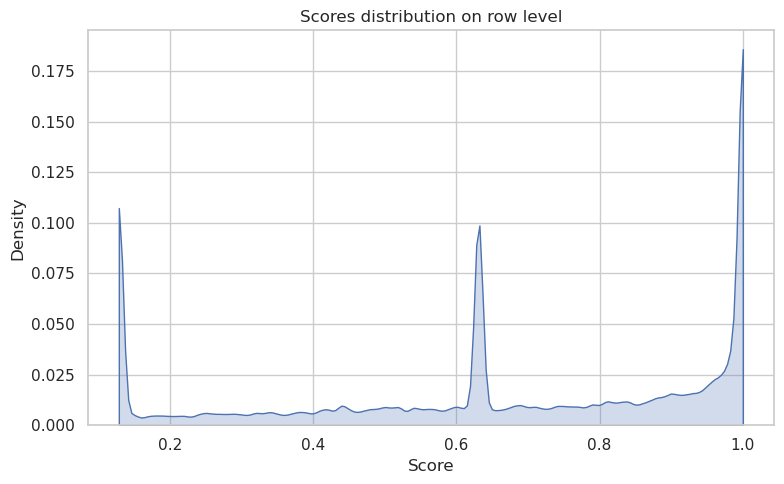

<Axes: title={'center': 'Scores distribution on row level'}, xlabel='Score', ylabel='Density'>

In [22]:
# base model plotting using .plot method
# df_scored["score"].plot.kde(ind=np.linspace(0, 1.0, 1000))

# using seaborn, logarithmic
plot_kdeplot(df_scored, "row", clip=[0.129, 1])

## merge variant into per-gene

### MAX approach

In [24]:
def merge_to_gene_max(df_scored: pd.DataFrame, gene_key: str = "ann_gene_id") -> pd.DataFrame:
    """Collapse variant/transcript rows to one row per gene.

    Maximum / worst-variant approach: each gene keeps the single annotation
    with the highest ``score``, so the gene-level risk equals its most
    damaging variant. The full worst-variant row is retained (effect, impact,
    SIFT, position) for context. Rows with no gene id are dropped.
    """
    scored = df_scored[df_scored[gene_key].fillna("").ne("")]
    idx = scored.groupby(gene_key)["score"].idxmax()       # worst variant per gene
    return (
        scored.loc[idx]
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )


df_scored_gene_max = merge_to_gene_max(df_scored)
df_scored_gene_max

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012877.2,59800110,T,TAG,56.779999,None,1/1,TAG,frameshift_variant,HIGH,...,FRAMESHIFT INSERTION,NA/NA,NA,NaN,NA,NA,NA,NA,NaN,1.0
1,NC_012870.2,65630769,A,G,27.889999,None,0|1,G,missense_variant,MODERATE,...,NONSYNONYMOUS,K/E,4,0.0,4.32,1,novel,DELETERIOUS (*WARNING! Low confidence),1.0,1.0
2,NC_012870.2,67734265,CCTGTTGCATTAGTA,C,33.830002,None,1/1,C,frameshift_variant,HIGH,...,FRAMESHIFT DELETION,NA/NA,NA,NaN,NA,NA,NA,NA,NaN,1.0
3,NC_012877.2,53132810,T,G,27.520000,None,1/1,G,missense_variant,MODERATE,...,NONSYNONYMOUS,I/L,136,0.0,4.32,1,novel,DELETERIOUS (*WARNING! Low confidence),1.0,1.0
4,NC_012871.2,54475620,C,A,46.790001,None,1/1,A,missense_variant,MODERATE,...,NONSYNONYMOUS,C/F,151,0.0,2.89,30,novel,DELETERIOUS,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36907,NC_012871.2,60128294,AC,A,28.850000,None,1/1,A,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
36908,NC_012871.2,59880524,G,A,29.920000,None,1/1,A,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
36909,NC_012871.2,59880524,G,A,29.920000,None,1/1,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
36910,NC_012871.2,59927659,C,CCT,22.910000,None,1/1,CCT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


### SUM approach

In [25]:
def merge_to_gene_sum(df_scored: pd.DataFrame, gene_key: str = "ann_gene_id") -> pd.DataFrame:
    """Collapse variant/transcript rows to one row per gene by summing scores.

    Sum approach: a gene's risk is the total of every annotation score it
    carries, so it rewards genes hit by many and/or more damaging variants
    (unlike the max approach, which only looks at the single worst variant).
    n_rows is kept alongside for context. Rows with no gene id are dropped.

    Note: SnpEff emits one row per transcript, so multi-transcript genes
    accumulate more rows; the sum reflects that transcript multiplicity.
    """
    scored = df_scored[df_scored[gene_key].fillna("").ne("")]
    return (
        scored.groupby(gene_key)
        .agg(
            score=("score", "sum"),
            n_rows=("score", "size"),
            ann_gene_name=("ann_gene_name", "first"),
        )
        .reset_index()
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )


df_scored_gene_sum = merge_to_gene_sum(df_scored)
df_scored_gene_sum

,ann_gene_id,score,n_rows,ann_gene_name
0,LOC8069102,105.649,351,LOC8069102
1,LOC8069091,87.143,273,LOC8069091
2,LOC110431053,60.096,272,LOC110431053
3,LOC8071440,59.839,280,LOC8071440
4,LOC8066704,59.223,125,LOC8066704
...,...,...,...,...
36907,LOC8060290,0.000,26,LOC8060290
36908,LOC8060277,0.000,1,LOC8060277
36909,LOC8060277-LOC8056001,0.000,40,LOC8060277-LOC8056001
36910,LOC8060278,0.000,1,LOC8060278


### Gene-length correction

In [26]:
# gene length (genomic span, bp) keyed by LOC gene id, from the NCBI GFF3
import gzip, re

GFF_PATH = "../resources/annot/GCF_000003195.3_Sorghum_bicolor_NCBIv3_genomic.gff.gz"


def load_gene_length(gff_path: str) -> dict:
    """Map gene Name (LOC...) -> genomic length in bp, from an NCBI GFF3.

    Parses 'gene' and 'pseudogene' features; length = end - start + 1 (genomic
    span, introns + UTRs). Keyed by the Name= attribute, which equals
    ann_gene_id for LOC-named genes. tRNA (SnpEff '..._N') and combo/intergenic
    keys won't match -> those genes get NaN length downstream.
    """
    lengths = {}
    opener = gzip.open if gff_path.endswith(".gz") else open
    with opener(gff_path, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.rstrip("\n").split("\t")
            if len(f) < 9 or f[2] not in ("gene", "pseudogene"):
                continue
            m = re.search(r"Name=([^;]+)", f[8])
            if m:
                lengths[m.group(1)] = int(f[4]) - int(f[3]) + 1
    return lengths


gene_length = load_gene_length(GFF_PATH)
print(f"{len(gene_length):,} genes;  LOC8061396 -> {gene_length.get('LOC8061396')} bp")

32,458 genes;  LOC8061396 -> 3176 bp


In [28]:
gene_length

{'LOC8081570': 1031,
 'LOC8059226': 3713,
 'LOC110434520': 1713,
 'LOC8059546': 18132,
 'LOC8059547': 9863,
 'LOC8059227': 5824,
 'LOC8060694': 1851,
 'LOC8059228': 25526,
 'LOC8059229': 2046,
 'LOC8061368': 3218,
 'LOC8059230': 20614,
 'LOC8061369': 697,
 'LOC110431639': 6654,
 'LOC8059231': 5790,
 'LOC110431007': 4803,
 'LOC8061371': 19904,
 'LOC110431992': 848,
 'LOC8059232': 1822,
 'LOC8059233': 2942,
 'LOC8059234': 1115,
 'LOC110431931': 3882,
 'LOC8059235': 1904,
 'LOC8059237': 3696,
 'LOC8061372': 3900,
 'LOC8059238': 3944,
 'LOC110431995': 3545,
 'LOC8059239': 7633,
 'LOC8059240': 1505,
 'LOC8061373': 5942,
 'LOC8059241': 1768,
 'LOC8059242': 2756,
 'LOC110430280': 2822,
 'LOC8059244': 4638,
 'LOC8059243': 2221,
 'LOC8059245': 2486,
 'LOC8059246': 5385,
 'LOC8061374': 5369,
 'LOC8059247': 1447,
 'LOC8059248': 10355,
 'LOC8059249': 1141,
 'LOC8061376': 4527,
 'LOC8059250': 807,
 'LOC8059251': 1170,
 'LOC8061377': 2279,
 'LOC8059252': 2238,
 'LOC8059253': 2665,
 'LOC110436541': 4

### MAX normalized by gene length

In [27]:
# max approach normalized by genomic gene length (score per kb)
def merge_to_gene_max_norm(df_scored: pd.DataFrame, gene_length: dict,
                           gene_key: str = "ann_gene_id", per_kb: bool = True) -> pd.DataFrame:
    """MAX gene score divided by genomic gene length (default: score per kb).

    Reuses merge_to_gene_max (full worst-variant row), then normalizes. The
    normalized value is named ``score`` (so plot_kdeplot works); the raw max is
    kept as score_raw. Genes with no length match (tRNA '_N', combo keys) ->
    NaN score.

    Note: max / length mostly re-ranks equal-max genes inversely by length.
    """
    g = merge_to_gene_max(df_scored, gene_key).rename(columns={"score": "score_raw"})
    g["gene_length"] = g[gene_key].map(gene_length)
    g["score"] = g["score_raw"] / g["gene_length"] * (1000 if per_kb else 1)
    return g.sort_values("score", ascending=False).reset_index(drop=True)


df_scored_gene_max_norm = merge_to_gene_max_norm(df_scored, gene_length)
df_scored_gene_max_norm

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score_raw,gene_length,score
0,NC_012871.2,50561358,C,CT,50.770000,None,1/1,CT,frameshift_variant,HIGH,...,NA,NaN,NA,NA,NA,NA,NaN,1.0,126.0,7.936508
1,NC_012876.2,15598868,T,C,32.009998,None,0|1,C,stop_lost&splice_region_variant,HIGH,...,101,NaN,NA,NA,novel,NA,NaN,1.0,303.0,3.300330
2,NC_012872.2,5054576,G,C,58.000000,None,1/1,C,missense_variant,MODERATE,...,28,0.0,4.32,171,novel,DELETERIOUS (*WARNING! Low confidence),1.0,1.0,318.0,3.144654
3,NC_012874.2,10160493,G,GC,39.070000,None,1|0,GC,frameshift_variant,HIGH,...,NA,NaN,NA,NA,NA,NA,NaN,1.0,324.0,3.086420
4,NC_012871.2,15327838,T,TC,35.430000,None,0|1,TC,frameshift_variant&stop_lost&splice_region_var...,HIGH,...,NA,NaN,NA,NA,NA,NA,NaN,1.0,330.0,3.030303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36907,NC_012871.2,59991804,G,GT,26.180000,None,1/1,GT,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
36908,NC_012871.2,59927659,C,CCT,22.910000,None,1/1,CCT,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
36909,NC_012871.2,60073700,T,TA,22.209999,None,0/1,TA,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
36910,NC_012871.2,59880524,G,A,29.920000,None,1/1,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


### SUM normalized by gene length

In [28]:
# sum approach normalized by genomic gene length (score per kb)
def merge_to_gene_sum_norm(df_scored: pd.DataFrame, gene_length: dict,
                           gene_key: str = "ann_gene_id", per_kb: bool = True) -> pd.DataFrame:
    """SUM gene score divided by genomic gene length (default: score per kb).

    Reuses merge_to_gene_sum, then normalizes. The normalized value is named
    ``score`` (so plot_kdeplot works); the raw sum is kept as score_raw.
    Genes with no length match (tRNA '_N', combo keys) -> NaN score.

    Note: length-normalization corrects for gene size only, NOT the SUM
    method's transcript-multiplicity inflation (see n_rows).
    """
    g = merge_to_gene_sum(df_scored, gene_key).rename(columns={"score": "score_raw"})
    g["gene_length"] = g[gene_key].map(gene_length)
    g["score"] = g["score_raw"] / g["gene_length"] * (1000 if per_kb else 1)
    return g.sort_values("score", ascending=False).reset_index(drop=True)


df_scored_gene_sum_norm = merge_to_gene_sum_norm(df_scored, gene_length)
df_scored_gene_sum_norm

,ann_gene_id,score_raw,n_rows,ann_gene_name,gene_length,score
0,LOC8081127,26.464,101,LOC8081127,618.0,42.822006
1,LOC8066370,58.891,152,LOC8066370,1857.0,31.712978
2,LOC8069102,105.649,351,LOC8069102,3483.0,30.332759
3,LOC8072467,44.803,186,LOC8072467,1688.0,26.542062
4,LOC8066889,9.750,22,LOC8066889,439.0,22.209567
...,...,...,...,...,...,...
36907,LOC8060282-LOC8060283,0.000,1,LOC8060282-LOC8060283,NaN,NaN
36908,LOC8060278-LOC8060280,0.000,4,LOC8060278-LOC8060280,NaN,NaN
36909,LOC8060286-LOC110432246,0.000,1,LOC8060286-LOC110432246,NaN,NaN
36910,LOC8060277-LOC8056001,0.000,40,LOC8060277-LOC8056001,NaN,NaN


## Compare all four approaches

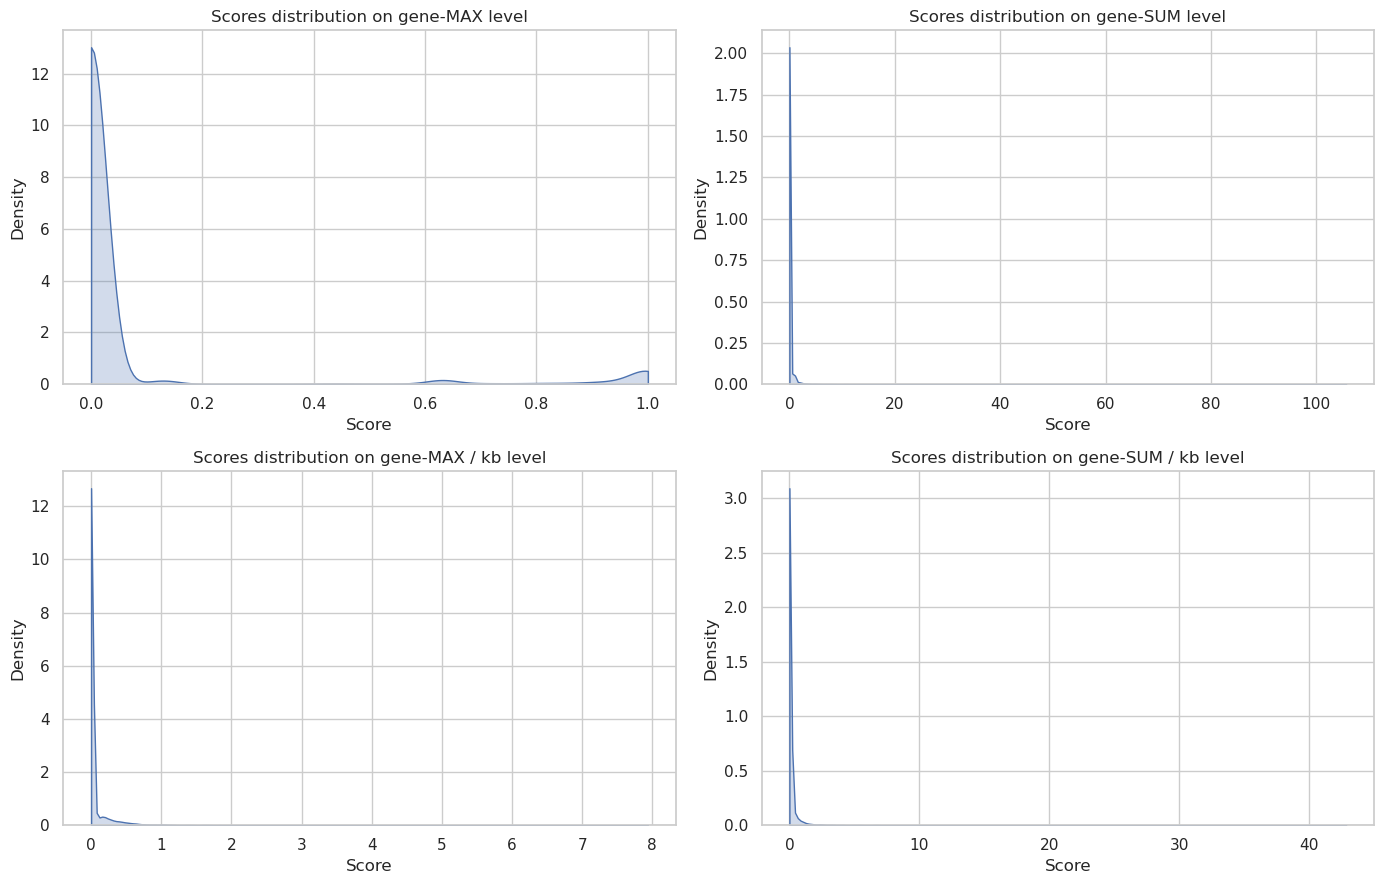

In [40]:
# compare all four gene-level approaches (each panel auto-scaled to its own range)
panels = [
    (df_scored_gene_max,      "gene-MAX",       None),
    (df_scored_gene_sum,      "gene-SUM",       None),
    (df_scored_gene_max_norm, "gene-MAX / kb",  None),
    (df_scored_gene_sum_norm, "gene-SUM / kb",  None),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for (d, t, c), ax in zip(panels, axes.flat):
    plot_kdeplot(d, t, ax=ax, clip=c)
fig.tight_layout()
plt.show()